In [ ]:
from google.colab import files
uploaded = files.upload()  # pick your dataset zip (the one with Participant folders)

zip_filename = list(uploaded.keys())[0]
print("Uploaded:", zip_filename)

import os, zipfile
DATASET_ROOT = "/content/punjabi_dataset_extracted"
os.makedirs(DATASET_ROOT, exist_ok=True)

with zipfile.ZipFile(zip_filename, 'r') as z:
    z.extractall(DATASET_ROOT)

# if there is a single top-level dir inside, descend into it
entries = [e for e in os.listdir(DATASET_ROOT) if not e.startswith('__')]
if len(entries) == 1 and os.path.isdir(os.path.join(DATASET_ROOT, entries[0])):
    DATASET_ROOT = os.path.join(DATASET_ROOT, entries[0])

print("✅ Extracted to:", DATASET_ROOT)
!apt-get -qq update && apt-get -qq install -y ffmpeg


Saving punjabi-Non discard-20251008T032331Z-1-001.zip to punjabi-Non discard-20251008T032331Z-1-001.zip
Uploaded: punjabi-Non discard-20251008T032331Z-1-001.zip
✅ Extracted to: /content/punjabi_dataset_extracted/punjabi-Non discard
W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)


In [ ]:
from google.colab import files
print("Upload punjabi_metadata_clean.csv (if you already have it). If you don't, cancel and go to Option B.")
uploaded = files.upload()


Upload punjabi_metadata_clean.csv (if you already have it). If you don't, cancel and go to Option B.


Saving punjabi_metadata_clean.csv to punjabi_metadata_clean.csv


In [ ]:
import pandas as pd, os, re
if 'punjabi_metadata_clean.csv' in uploaded:
    df_meta = pd.read_csv('/content/punjabi_metadata_clean.csv')
    print("Loaded existing metadata:", df_meta.shape)
else:
    print("No existing metadata found in upload; will generate in Option B.")


Loaded existing metadata: (1240, 8)


In [ ]:
import os, glob, subprocess, pandas as pd

# convert all mp3 under DATASET_ROOT to wav (mono 16k)
mp3_files = glob.glob(os.path.join(DATASET_ROOT, '**', '*.mp3'), recursive=True)
print("MP3 files found:", len(mp3_files))
converted=0
for mp3 in mp3_files:
    wav = mp3[:-4] + '.wav'
    if os.path.exists(wav):
        continue
    try:
        subprocess.run(["ffmpeg","-y","-i", mp3, "-ac","1","-ar","16000", wav],
                       check=True, stdout=subprocess.PIPE, stderr=subprocess.PIPE)
        converted += 1
    except subprocess.CalledProcessError:
        print("❌ convert failed:", mp3)
print("WAV newly created:", converted)

# rebuild resolved_path from relpath, forcing .wav
df = df_meta.copy()
def rel_to_wav(rel):
    rel = str(rel).strip().strip("'").strip('"').replace("\\","/")
    if rel.lower().endswith(".mp3"): rel = rel[:-4]+".wav"
    elif not rel.lower().endswith(".wav"): rel = rel + ".wav"
    return os.path.normpath(os.path.join(DATASET_ROOT, rel))
df['resolved_path'] = df['relpath'].apply(rel_to_wav)

# keep only rows with existing wav
exists = df['resolved_path'].apply(lambda p: isinstance(p,str) and os.path.exists(p))
print("Resolved WAVs that exist:", exists.sum(), "/", len(df))
df_ok = df[exists].reset_index(drop=True)
df_ok.to_csv('/content/punjabi_metadata_resolved.csv', index=False)
print("✅ Saved resolved metadata:", df_ok.shape)

# quick load test
import librosa
test_file = df_ok['resolved_path'].iloc[0]
y, sr = librosa.load(test_file, sr=16000, mono=True)
print("Loaded OK:", test_file, "len:", len(y))


MP3 files found: 1240
WAV newly created: 1240
Resolved WAVs that exist: 1240 / 1240
✅ Saved resolved metadata: (1240, 9)
Loaded OK: /content/punjabi_dataset_extracted/punjabi-Non discard/Participant 3/2. Happy/8.2.wav len: 49737


#Re extraction

In [ ]:
!pip install librosa soundfile tqdm praat-parselmouth numpy scipy --quiet


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.7/10.7 MB 25.6 MB/s eta 0:00:00


In [ ]:
import numpy as np, pandas as pd, librosa, parselmouth
from parselmouth.praat import call
from tqdm import tqdm
from scipy.stats import linregress
import soundfile as sf

def _safe_mean(x):
    x = np.asarray(x); x = x[np.isfinite(x)]
    return float(np.mean(x)) if x.size else np.nan

def _pitch_features(y, sr, fmin=75, fmax=500):
    try:
        snd = parselmouth.Sound(y, sr)
        pitch = snd.to_pitch(time_step=0.01, pitch_floor=fmin, pitch_ceiling=fmax)
        f0 = pitch.selected_array['frequency']; times = pitch.xs()
        voiced = f0 > 0
        f0v = f0[voiced]; tv = times[voiced]

        return {
            'f0_mean': _safe_mean(f0v),
            'f0_std': _safe_mean(np.std(f0v)) if f0v.size else np.nan,
            'f0_min': float(np.min(f0v)) if f0v.size else np.nan,
            'f0_max': float(np.max(f0v)) if f0v.size else np.nan,
            'f0_slope': linregress(tv, f0v).slope if f0v.size > 3 else np.nan,
            'f0_delta_std': np.std(np.diff(f0v)) if f0v.size > 3 else np.nan,
            'voiced_fraction': float(np.mean(voiced)) if f0.size else np.nan
        }
    except Exception:
        return {
            'f0_mean': np.nan, 'f0_std': np.nan, 'f0_min': np.nan, 'f0_max': np.nan,
            'f0_slope': np.nan, 'f0_delta_std': np.nan, 'voiced_fraction': np.nan
        }

def _voice_quality(y, sr):
    try:
        snd = parselmouth.Sound(y, sr)
        # PointProcess for jitter/shimmer
        pp = call(snd, "To PointProcess (periodic, cc)", 75, 500)

        # Jitter: point process only
        jitter = call(pp, "Get jitter (local)", 0, 0, 0.0001, 0.02, 1.3)

        # Shimmer: sound + point process
        shimmer = call([snd, pp], "Get shimmer (local)", 0, 0, 0.0001, 0.02, 1.3, 1.6)

        # HNR: from harmonicity object
        hnr_obj = call(snd, "To Harmonicity (cc)", 0.01, 75, 0.1, 1.0)
        hnr = call(hnr_obj, "Get mean", 0, 0)

        return {
            'jitter_local': float(jitter),
            'shimmer_local': float(shimmer),
            'hnr_db': float(hnr)
        }
    except Exception as e:
        # If anything fails for this file, return NaNs (don’t crash the whole run)
        return {
            'jitter_local': np.nan,
            'shimmer_local': np.nan,
            'hnr_db': np.nan
        }

def _rhythm_silence(y, sr, top_db=30):
    intervals = librosa.effects.split(y, top_db=top_db)
    dur = len(y)/sr
    speech_dur = np.sum((intervals[:,1]-intervals[:,0]))/sr if intervals.size else 0.0
    silence_ratio = 1 - (speech_dur/dur if dur>0 else 0.0)
    bursts_per_sec = (len(intervals)/dur) if dur>0 else 0.0
    avg_pause = 0.0
    if intervals.size >= 2:
        pauses = (intervals[1:,0]-intervals[:-1,1])/sr
        avg_pause = float(np.mean(pauses))
    return {'silence_ratio':float(silence_ratio),'bursts_per_sec':float(bursts_per_sec),
            'avg_pause_sec':float(avg_pause),'duration_sec':float(dur)}

def _spectral_shape(y, sr):
    S = np.abs(librosa.stft(y, n_fft=1024, hop_length=256))**2
    if S.size == 0:
        return {k: np.nan for k in ['centroid_mean','centroid_std','bandwidth_mean','bandwidth_std','rolloff50_mean','rolloff85_mean','spectral_slope']}
    centroid = librosa.feature.spectral_centroid(S=S, sr=sr)[0]
    bandwidth = librosa.feature.spectral_bandwidth(S=S, sr=sr)[0]
    roll50 = librosa.feature.spectral_rolloff(S=S, sr=sr, roll_percent=0.50)[0]
    roll85 = librosa.feature.spectral_rolloff(S=S, sr=sr, roll_percent=0.85)[0]
    mean_spec = np.mean(S, axis=1) + 1e-12
    freqs = librosa.fft_frequencies(sr=sr, n_fft=1024)
    slope = linregress(freqs, np.log10(mean_spec)).slope
    return {'centroid_mean': _safe_mean(centroid), 'centroid_std': _safe_mean(np.std(centroid)),
            'bandwidth_mean': _safe_mean(bandwidth),'bandwidth_std': _safe_mean(np.std(bandwidth)),
            'rolloff50_mean': _safe_mean(roll50), 'rolloff85_mean': _safe_mean(roll85),
            'spectral_slope': float(slope)}

def _base_features(y, sr):
    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13)
    chroma = librosa.feature.chroma_stft(y=y, sr=sr)
    contrast = librosa.feature.spectral_contrast(y=y, sr=sr)
    zcr = librosa.feature.zero_crossing_rate(y)[0]
    rms = librosa.feature.rms(y=y)[0]
    feats = {}
    for i,v in enumerate(np.mean(mfcc,axis=1)): feats[f'mfcc_mean_{i}']=float(v)
    for i,v in enumerate(np.std(mfcc,axis=1)):  feats[f'mfcc_std_{i}']=float(v)
    for i,v in enumerate(np.mean(chroma,axis=1)): feats[f'chroma_mean_{i}']=float(v)
    for i,v in enumerate(np.std(chroma,axis=1)):  feats[f'chroma_std_{i}']=float(v)
    for i,v in enumerate(np.mean(contrast,axis=1)): feats[f'contrast_mean_{i}']=float(v)
    for i,v in enumerate(np.std(contrast,axis=1)):  feats[f'contrast_std_{i}']=float(v)
    feats['zcr_mean']=float(np.mean(zcr)); feats['zcr_std']=float(np.std(zcr))
    feats['rms_mean']=float(np.mean(rms)); feats['rms_std']=float(np.std(rms))
    return feats

def _formants(y, sr):
    try:
        snd = parselmouth.Sound(y, sr)
        form = call(snd, "To Formant (burg)", 0.01, 5, 5500, 0.025, 50)
        dur = len(y)/sr
        times = np.linspace(0.05, max(0.051, dur-0.05), num=max(2, int(dur*10)))
        F1, F2 = [], []
        for t in times:
            f1 = call(form, "Get value at time", 1, t, 'Hertz', 'Linear')
            f2 = call(form, "Get value at time", 2, t, 'Hertz', 'Linear')
            if np.isfinite(f1): F1.append(f1)
            if np.isfinite(f2): F2.append(f2)
        return {'F1_mean': float(np.mean(F1)) if F1 else np.nan,
                'F2_mean': float(np.mean(F2)) if F2 else np.nan}
    except:
        return {'F1_mean': np.nan, 'F2_mean': np.nan}

def is_valid_audio(path):
    try:
        sf.info(path)
        return True
    except:
        return False

df_ok = pd.read_csv('/content/punjabi_metadata_resolved.csv')
df_ok = df_ok[df_ok['resolved_path'].apply(is_valid_audio)].reset_index(drop=True)
print("Valid audio files:", len(df_ok))

rows = []
for _, r in tqdm(df_ok.iterrows(), total=len(df_ok), desc="Extracting features"):
    y, sr = librosa.load(r['resolved_path'], sr=16000, mono=True)
    feats = {}
    feats.update(_base_features(y, sr))
    feats.update(_pitch_features(y, sr))
    feats.update(_voice_quality(y, sr))
    feats.update(_rhythm_silence(y, sr))
    feats.update(_spectral_shape(y, sr))
    feats.update(_formants(y, sr))
    feats.update({
        'filepath': r['resolved_path'],
        'relpath': r.get('relpath',''),
        'participant': r.get('participant',''),
        'file_name': r.get('file_name',''),
        'emotion_clean': r.get('emotion_clean',''),
        'label_id': r.get('label_id', -1)
    })
    rows.append(feats)

feat_df = pd.DataFrame(rows)
OUT_CSV = "/content/punjabi_audio_features_prosody_with_ids.csv"
feat_df.to_csv(OUT_CSV, index=False)
print("✅ Saved features ->", OUT_CSV, "shape:", feat_df.shape)
feat_df.head()


Valid audio files: 1240


Extracting features:   0%|          | 0/1240 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/numpy/_core/fromnumeric.py:3596: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:138: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
Extracting features: 100%|██████████| 1240/1240 [04:10<00:00,  4.96it/s]


✅ Saved features -> /content/punjabi_audio_features_prosody_with_ids.csv shape: (1240, 97)


,mfcc_mean_0,mfcc_mean_1,mfcc_mean_2,mfcc_mean_3,mfcc_mean_4,mfcc_mean_5,mfcc_mean_6,mfcc_mean_7,mfcc_mean_8,mfcc_mean_9,...,rolloff85_mean,spectral_slope,F1_mean,F2_mean,filepath,relpath,participant,file_name,emotion_clean,label_id
0,-402.299835,84.412430,2.373559,24.711140,-15.431018,6.345286,-9.797523,5.692486,-8.334229,-1.878310,...,732.772436,-0.000454,765.126335,2065.666079,/content/punjabi_dataset_extracted/punjabi-Non...,Participant 3/2. Happy/8.2.mp3,Participant 3,8.2.mp3,happy,2
1,-461.731323,67.154114,12.757621,25.388544,-6.708074,7.278314,1.290177,2.234398,-4.029228,2.704566,...,469.500546,-0.000656,934.316438,2115.032236,/content/punjabi_dataset_extracted/punjabi-Non...,Participant 3/2. Happy/10.2.mp3,Participant 3,10.2.mp3,happy,2
2,-465.266418,59.366291,23.789635,28.923706,1.652424,14.547934,5.153780,-4.915718,-0.381506,1.328020,...,629.681420,-0.000119,768.681291,2067.838452,/content/punjabi_dataset_extracted/punjabi-Non...,Participant 3/2. Happy/14.2.mp3,Participant 3,14.2.mp3,happy,2
3,-438.507812,78.936821,4.724331,37.148098,-8.956104,4.742302,1.965555,6.472157,-5.370359,3.931255,...,448.138298,-0.000689,850.264191,2123.296371,/content/punjabi_dataset_extracted/punjabi-Non...,Participant 3/2. Happy/5.2.mp3,Participant 3,5.2.mp3,happy,2
4,-388.898560,82.725708,-8.654634,32.088013,-3.730554,4.826180,0.401049,5.972783,3.200714,-0.940843,...,485.726351,-0.000672,892.603200,2015.096575,/content/punjabi_dataset_extracted/punjabi-Non...,Participant 3/2. Happy/3.2.mp3,Participant 3,3.2.mp3,happy,2


In [ ]:
import pandas as pd, numpy as np, os, joblib
from sklearn.model_selection import GroupShuffleSplit
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight
from sklearn.neural_network import MLPClassifier

df = pd.read_csv('/content/punjabi_audio_features_prosody_with_ids.csv').dropna(subset=['emotion_clean'])

# feature blocks (all, not just first N)
feature_cols = [c for c in df.columns if any([
    c.startswith('mfcc_mean_'), c.startswith('mfcc_std_'),
    c.startswith('chroma_mean_'), c.startswith('chroma_std_'),
    c.startswith('contrast_mean_'), c.startswith('contrast_std_'),
    c in ['zcr_mean','zcr_std','rms_mean','rms_std',
          'f0_mean','f0_std','f0_min','f0_max','f0_slope','f0_delta_std','voiced_fraction',
          'jitter_local','shimmer_local','hnr_db','silence_ratio','bursts_per_sec','avg_pause_sec','duration_sec',
          'centroid_mean','centroid_std','bandwidth_mean','bandwidth_std','rolloff50_mean','rolloff85_mean','spectral_slope',
          'F1_mean','F2_mean']
])]

# speaker-wise split
gss = GroupShuffleSplit(test_size=0.25, n_splits=1, random_state=42)
tr_idx, te_idx = next(gss.split(df, groups=df['participant']))
train = df.iloc[tr_idx].reset_index(drop=True)
test  = df.iloc[te_idx].reset_index(drop=True)

# numeric
train[feature_cols] = train[feature_cols].apply(pd.to_numeric, errors='coerce')
test[feature_cols]  = test[feature_cols].apply(pd.to_numeric, errors='coerce')

# inf -> NaN
train[feature_cols] = train[feature_cols].replace([np.inf,-np.inf], np.nan)
test[feature_cols]  = test[feature_cols].replace([np.inf,-np.inf], np.nan)

# drop all-NaN columns (in TRAIN)
all_nan_cols = train[feature_cols].columns[train[feature_cols].isna().all()].tolist()
if all_nan_cols:
    feature_cols = [c for c in feature_cols if c not in all_nan_cols]
    train = train.drop(columns=all_nan_cols)
    test  = test.drop(columns=all_nan_cols, errors='ignore')

# impute (fit on train only)
imputer = SimpleImputer(strategy='median')
Xtr = imputer.fit_transform(train[feature_cols])
Xte = imputer.transform(test[feature_cols])
joblib.dump(imputer, '/content/imputer.joblib')

# scale (fit on train only)
scaler = StandardScaler()
Xtr_s = scaler.fit_transform(Xtr)
Xte_s = scaler.transform(Xte)
joblib.dump(scaler, '/content/scaler.joblib')

ytr = train['emotion_clean'].values
yte = test['emotion_clean'].values

# RF Top-K selection (balanced)
classes = np.unique(ytr)
cw = compute_class_weight('balanced', classes=classes, y=ytr)
cw = {c:w for c,w in zip(classes, cw)}
rf_fs = RandomForestClassifier(n_estimators=500, random_state=42, class_weight=cw, n_jobs=-1)
rf_fs.fit(Xtr_s, ytr)
imp = pd.DataFrame({'feature': feature_cols, 'importance': rf_fs.feature_importances_}).sort_values('importance', ascending=False)
TOP_K = 50
top_features = imp.head(TOP_K)['feature'].tolist()
top_idx = [feature_cols.index(c) for c in top_features]

# RF on Top-K
rf = RandomForestClassifier(n_estimators=700, random_state=42, class_weight='balanced', n_jobs=-1)
rf.fit(Xtr_s[:, top_idx], ytr)
pred_rf = rf.predict(Xte_s[:, top_idx])
print("\n--- RF (Top-K) ---")
print(classification_report(yte, pred_rf))
print(confusion_matrix(yte, pred_rf))

# PCA (90%)
pca = PCA(n_components=0.90, random_state=42)
Xtr_p = pca.fit_transform(Xtr_s)
Xte_p = pca.transform(Xte_s)
print("PCA comps:", pca.n_components_)
joblib.dump(pca, '/content/pca_model.joblib')

# MLP on PCA
mlp = MLPClassifier(hidden_layer_sizes=(256,128), max_iter=600, random_state=42)
mlp.fit(Xtr_p, ytr)
pred_mlp = mlp.predict(Xte_p)
print("\n--- MLP (PCA) ---")
print(classification_report(yte, pred_mlp))
print(confusion_matrix(yte, pred_mlp))



--- RF (Top-K) ---
              precision    recall  f1-score   support

       anger       0.82      0.93      0.88        75
        fear       0.74      0.45      0.56        75
       happy       0.72      0.77      0.75        75
     neutral       0.43      0.44      0.44        75
         sad       0.51      0.60      0.55        75

    accuracy                           0.64       375
   macro avg       0.65      0.64      0.63       375
weighted avg       0.65      0.64      0.63       375

[[70  0  2  3  0]
 [ 4 34  9 11 17]
 [ 3  1 58 13  0]
 [ 8  2  6 33 26]
 [ 0  9  5 16 45]]
PCA comps: 34

--- MLP (PCA) ---
              precision    recall  f1-score   support

       anger       0.75      0.96      0.84        75
        fear       0.70      0.40      0.51        75
       happy       0.71      0.68      0.69        75
     neutral       0.49      0.43      0.46        75
         sad       0.49      0.65      0.56        75

    accuracy                           0.

#some changes

In [ ]:
import numpy as np, pandas as pd, joblib, lightgbm as lgb
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix, f1_score
from sklearn.model_selection import GroupShuffleSplit

# --- load the same processed train/test tensors you just used ---
# Recreate split & preprocessing in the SAME way you did for the RF Top-K step:
df = pd.read_csv('/content/punjabi_audio_features_prosody_with_ids.csv').dropna(subset=['emotion_clean'])

feature_cols = [c for c in df.columns if any([
    c.startswith('mfcc_mean_'), c.startswith('mfcc_std_'),
    c.startswith('chroma_mean_'), c.startswith('chroma_std_'),
    c.startswith('contrast_mean_'), c.startswith('contrast_std_'),
    c in ['zcr_mean','zcr_std','rms_mean','rms_std','f0_mean','f0_std','f0_min','f0_max','f0_slope','f0_delta_std','voiced_fraction',
          'jitter_local','shimmer_local','hnr_db','silence_ratio','bursts_per_sec','avg_pause_sec','duration_sec',
          'centroid_mean','centroid_std','bandwidth_mean','bandwidth_std','rolloff50_mean','rolloff85_mean','spectral_slope',
          'F1_mean','F2_mean']
])]

# repeat the same GroupShuffleSplit, imputer, scaler you used earlier:
from sklearn.model_selection import GroupShuffleSplit
gss = GroupShuffleSplit(test_size=0.25, n_splits=1, random_state=42)
tr_idx, te_idx = next(gss.split(df, groups=df['participant']))
train = df.iloc[tr_idx].reset_index(drop=True)
test  = df.iloc[te_idx].reset_index(drop=True)

# numeric + inf→NaN
train[feature_cols] = train[feature_cols].apply(pd.to_numeric, errors='coerce').replace([np.inf,-np.inf], np.nan)
test[feature_cols]  = test[feature_cols].apply(pd.to_numeric, errors='coerce').replace([np.inf,-np.inf], np.nan)

# drop all-NaN cols on TRAIN
from sklearn.impute import SimpleImputer
all_nan_cols = train[feature_cols].columns[train[feature_cols].isna().all()].tolist()
feature_cols = [c for c in feature_cols if c not in all_nan_cols]
train = train.drop(columns=all_nan_cols)
test  = test.drop(columns=all_nan_cols, errors='ignore')

# impute (train only) + scale (train only)
imputer = SimpleImputer(strategy='median')
Xtr = imputer.fit_transform(train[feature_cols])
Xte = imputer.transform(test[feature_cols])

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
Xtr_s = scaler.fit_transform(Xtr)
Xte_s = scaler.transform(Xte)

ytr = train['emotion_clean'].values
yte = test['emotion_clean'].values
classes = np.unique(ytr)
cw_vals = compute_class_weight('balanced', classes=classes, y=ytr)
class_weight = {c:w for c,w in zip(classes, cw_vals)}

# ---- reuse Top-K list you got from RF selection (if you have it). If not, derive again quickly:
from sklearn.ensemble import RandomForestClassifier
rf_fs = RandomForestClassifier(n_estimators=500, random_state=42, class_weight=class_weight, n_jobs=-1)
rf_fs.fit(Xtr_s, ytr)
imp = pd.DataFrame({'feature': feature_cols, 'importance': rf_fs.feature_importances_}).sort_values('importance', ascending=False)
TOP_K = 50
top_features = imp.head(TOP_K)['feature'].tolist()
top_idx = [feature_cols.index(c) for c in top_features]

# ---- LightGBM with callbacks (new API)
lgbm = lgb.LGBMClassifier(
    n_estimators=3000,
    learning_rate=0.03,
    num_leaves=63,
    max_depth=-1,
    subsample=0.9,
    colsample_bytree=0.9,
    random_state=42,
    class_weight=class_weight
)
# make a small validation cut from training for early stopping (speaker-wise)
from sklearn.model_selection import GroupShuffleSplit
gss2 = GroupShuffleSplit(test_size=0.15, n_splits=1, random_state=123)
tr2_idx, val_idx = next(gss2.split(train, groups=train['participant']))
X_tr2, y_tr2 = Xtr_s[tr2_idx][:, top_idx], ytr[tr2_idx]
X_val,  y_val  = Xtr_s[val_idx][:,  top_idx], ytr[val_idx]

lgbm.fit(
    X_tr2, y_tr2,
    eval_set=[(X_val, y_val)],
    callbacks=[lgb.early_stopping(100), lgb.log_evaluation(0)]
)

# test eval
pred = lgbm.predict(Xte_s[:, top_idx])
print("\n--- LightGBM (Top-K, class-weighted) ---")
print(classification_report(yte, pred))
print(confusion_matrix(yte, pred))

# keep probabilities for threshold tuning & ensembling
probs_lgb = lgbm.predict_proba(Xte_s[:, top_idx])


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000573 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 11838
[LightGBM] [Info] Number of data points in the train set: 719, number of used features: 50
[LightGBM] [Info] Start training from score -1.604424
[LightGBM] [Info] Start training from score -1.621620
[LightGBM] [Info] Start training from score -1.603311
[LightGBM] [Info] Start training from score -1.611250
[LightGBM] [Info] Start training from score -1.606695
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
Training until validation scores don't improve for 100 rounds
[Ligh

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [ ]:
# ===========================================
# Block-aware Top-K + CV-averaged importances + LGBM + per-class thresholds
# Colab-ready single cell
# ===========================================
import os, numpy as np, pandas as pd, joblib, lightgbm as lgb
from sklearn.model_selection import GroupShuffleSplit, GroupKFold
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_class_weight
from sklearn.ensemble import RandomForestClassifier
from sklearn.decomposition import PCA
from sklearn.metrics import classification_report, confusion_matrix, precision_recall_curve
from collections import defaultdict

# --------------------
# Config
# --------------------
FEATURES_CSV = '/content/punjabi_audio_features_prosody_with_ids.csv'  # CHANGE if needed
TEST_SIZE = 0.25                      # speaker-wise split
VAL_SIZE = 0.15                       # speaker-wise validation slice (from train) for early stopping + thresholds
TOP_K = 50                            # total Top-K features
QUOTAS = {'mfcc': 20, 'chroma': 8, 'contrast': 8, 'prosody': 12}  # must sum <= TOP_K
RANDOM_STATE = 42

# --------------------
# Load & identify feature families
# --------------------
df = pd.read_csv(FEATURES_CSV).dropna(subset=['emotion_clean'])
assert 'participant' in df.columns, "Missing 'participant' column in features CSV."
feature_cols_all = []

def has(c):
    return c in df.columns

mfcc_cols     = [c for c in df.columns if c.startswith('mfcc_')]
chroma_cols   = [c for c in df.columns if c.startswith('chroma_')]
contrast_cols = [c for c in df.columns if c.startswith('contrast_')]
prosody_list  = [
    'zcr_mean','zcr_std','rms_mean','rms_std',
    'f0_mean','f0_std','f0_min','f0_max','f0_slope','f0_delta_std','voiced_fraction',
    'jitter_local','shimmer_local','hnr_db',
    'silence_ratio','bursts_per_sec','avg_pause_sec','duration_sec',
    'centroid_mean','centroid_std','bandwidth_mean','bandwidth_std',
    'rolloff50_mean','rolloff85_mean','spectral_slope',
    'F1_mean','F2_mean'
]
prosody_cols  = [c for c in prosody_list if has(c)]

feature_cols = mfcc_cols + chroma_cols + contrast_cols + prosody_cols
assert len(feature_cols) > 0, "No feature columns detected."

print(f"Detected features -> MFCC:{len(mfcc_cols)}  Chroma:{len(chroma_cols)}  Contrast:{len(contrast_cols)}  Prosody:{len(prosody_cols)}  Total:{len(feature_cols)}")
print("Emotions:", sorted(df['emotion_clean'].unique()))

# --------------------
# Speaker-wise train/test split
# --------------------
gss = GroupShuffleSplit(test_size=TEST_SIZE, n_splits=1, random_state=RANDOM_STATE)
tr_idx, te_idx = next(gss.split(df, groups=df['participant']))
train = df.iloc[tr_idx].reset_index(drop=True)
test  = df.iloc[te_idx].reset_index(drop=True)

# numeric coercion, inf->NaN
train[feature_cols] = train[feature_cols].apply(pd.to_numeric, errors='coerce').replace([np.inf, -np.inf], np.nan)
test[feature_cols]  = test[feature_cols].apply(pd.to_numeric, errors='coerce').replace([np.inf, -np.inf], np.nan)

# drop all-NaN cols in TRAIN (and mirror on test)
all_nan_cols = train[feature_cols].columns[train[feature_cols].isna().all()].tolist()
if all_nan_cols:
    print("Dropping all-NaN columns in TRAIN:", all_nan_cols)
    feature_cols = [c for c in feature_cols if c not in all_nan_cols]
    train = train.drop(columns=all_nan_cols)
    test  = test.drop(columns=all_nan_cols, errors='ignore')

# impute (fit on train) + scale (fit on train)
imputer = SimpleImputer(strategy='median')
Xtr = imputer.fit_transform(train[feature_cols])
Xte = imputer.transform(test[feature_cols])
joblib.dump(imputer, '/content/imputer.joblib')

scaler = StandardScaler()
Xtr_s = scaler.fit_transform(Xtr)
Xte_s = scaler.transform(Xte)
joblib.dump(scaler, '/content/scaler.joblib')

ytr = train['emotion_clean'].values
yte = test['emotion_clean'].values
labels = np.unique(ytr)

# --------------------
# GroupKFold-averaged RF importances on TRAIN
# --------------------
gkf = GroupKFold(n_splits=5)
groups_tr = train['participant'].values

cw_vals = compute_class_weight('balanced', classes=labels, y=ytr)
class_weight_dict = {lab: w for lab, w in zip(labels, cw_vals)}

imp_sum = np.zeros(len(feature_cols), dtype=float)
for fold, (a, b) in enumerate(gkf.split(Xtr_s, ytr, groups_tr), 1):
    rf = RandomForestClassifier(n_estimators=500, random_state=RANDOM_STATE+fold,
                                class_weight=class_weight_dict, n_jobs=-1)
    rf.fit(Xtr_s[a], ytr[a])
    imp_sum += rf.feature_importances_
imp_avg = imp_sum / 5.0

imp_df = pd.DataFrame({'feature': feature_cols, 'importance': imp_avg}).sort_values('importance', ascending=False)

# map feature -> group for block-aware Top-K
group_map = {}
for c in mfcc_cols:     group_map[c] = 'mfcc'
for c in chroma_cols:   group_map[c] = 'chroma'
for c in contrast_cols: group_map[c] = 'contrast'
for c in prosody_cols:  group_map[c] = 'prosody'
imp_df['group'] = imp_df['feature'].map(group_map).fillna('other')

# Block-aware selection with quotas
selected = []
for g, q in QUOTAS.items():
    got = (imp_df[imp_df['group']==g]
           .sort_values('importance', ascending=False)
           .head(q)['feature'].tolist())
    selected += got

if len(selected) < TOP_K:
    spill = (imp_df[~imp_df['feature'].isin(selected)]
             .sort_values('importance', ascending=False)
             .head(TOP_K - len(selected))['feature'].tolist())
    selected += spill

top_features = selected[:TOP_K]
print(f"Top-K={TOP_K} selected (block-aware):")
by_group = defaultdict(int)
for f in top_features:
    by_group[group_map.get(f, 'other')] += 1
print(dict(by_group))

# indices for slicing the scaled matrix
top_idx = [feature_cols.index(c) for c in top_features]

# Save Top-K list
pd.Series(top_features, name='feature').to_csv('/content/topk_features.csv', index=False)

# --------------------
# Build a speaker-wise validation slice from TRAIN (for early stopping & thresholds)
# --------------------
gss_val = GroupShuffleSplit(test_size=VAL_SIZE, n_splits=1, random_state=RANDOM_STATE+99)
tr2_idx, val_idx = next(gss_val.split(train, groups=train['participant']))

X_tr2, y_tr2 = Xtr_s[tr2_idx][:, top_idx], ytr[tr2_idx]
X_val,  y_val  = Xtr_s[val_idx][:,  top_idx], ytr[val_idx]

# --------------------
# LightGBM (class-weighted) with early stopping
# --------------------
lgbm = lgb.LGBMClassifier(
    n_estimators=3000,
    learning_rate=0.03,
    num_leaves=63,
    max_depth=-1,
    subsample=0.9,
    colsample_bytree=0.9,
    random_state=RANDOM_STATE,
    class_weight=class_weight_dict
)

lgbm.fit(
    X_tr2, y_tr2,
    eval_set=[(X_val, y_val)],
    callbacks=[lgb.early_stopping(100), lgb.log_evaluation(0)]
)

# Test evaluation (argmax)
pred_test = lgbm.predict(Xte_s[:, top_idx])
print("\n--- LightGBM TEST (argmax) ---")
print(classification_report(yte, pred_test, digits=3))
print(confusion_matrix(yte, pred_test))

# --------------------
# Per-class threshold tuning (optimize F1 per class on VAL), then apply to TEST
# --------------------
val_probs = lgbm.predict_proba(X_val)
thr = np.full(len(labels), 0.5, dtype=float)

for i, lab in enumerate(labels):
    y_true = (y_val == lab).astype(int)
    prec, rec, th = precision_recall_curve(y_true, val_probs[:, i])
    f1 = 2*prec*rec/(prec+rec+1e-12)
    if len(th) > 0 and np.isfinite(f1).any():
        thr[i] = th[np.nanargmax(f1)]

print("Best per-class thresholds:", dict(zip(labels, np.round(thr, 3))))
joblib.dump({'labels': labels, 'thresholds': thr}, '/content/thresholds.joblib')

def predict_with_thresholds(proba, thresholds):
    adj = proba - thresholds.reshape(1, -1)
    pred = np.argmax(adj, axis=1)
    below = (proba < thresholds).all(axis=1)
    # fallback: pure argmax when all below thresholds
    pred[below] = np.argmax(proba[below], axis=1)
    return pred

test_probs = lgbm.predict_proba(Xte_s[:, top_idx])
pred_thr_idx = predict_with_thresholds(test_probs, thr)
pred_thr = np.array([labels[i] for i in pred_thr_idx])

print("\n--- LightGBM TEST (per-class thresholds) ---")
print(classification_report(yte, pred_thr, digits=3))
print(confusion_matrix(yte, pred_thr))

# --------------------
# Save final artifacts
# --------------------
joblib.dump(lgbm, '/content/lgbm_topk.joblib')
print("\nArtifacts saved:")
print(" - /content/imputer.joblib")
print(" - /content/scaler.joblib")
print(" - /content/topk_features.csv")
print(" - /content/lgbm_topk.joblib")
print(" - /content/thresholds.joblib")


Detected features -> MFCC:26  Chroma:24  Contrast:14  Prosody:27  Total:91
Emotions: ['anger', 'fear', 'happy', 'neutral', 'sad']
Top-K=50 selected (block-aware):
{'mfcc': 20, 'chroma': 8, 'contrast': 8, 'prosody': 14}
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000528 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 11856
[LightGBM] [Info] Number of data points in the train set: 721, number of used features: 50
[LightGBM] [Info] Start training from score -1.600376
[LightGBM] [Info] Start training from score -1.624351
[LightGBM] [Info] Start training from score -1.606042
[LightGBM] [Info] Start training from score -1.607155
[LightGBM] [Info] Start training from score -1.609426
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -in

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [ ]:
# =====================================
# PCA (95% variance) + MLP + Ensemble w/ LGBM
# =====================================
from sklearn.decomposition import PCA
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report, confusion_matrix, precision_recall_curve
import joblib, numpy as np, pandas as pd

print("\n🔧 Running PCA (retain 95% variance)...")

# PCA = fit on TRAIN only
pca = PCA(n_components=0.95, random_state=42)
Xtr_p = pca.fit_transform(Xtr_s)
Xte_p = pca.transform(Xte_s)
joblib.dump(pca, "/content/pca_95.joblib")

print(f"✅ PCA components kept: {pca.n_components_}")

# ------------------------------
# Train MLP on PCA
# ------------------------------
print("\n🤖 Training MLP on PCA features...")

mlp = MLPClassifier(
    hidden_layer_sizes=(256,128),
    activation='relu',
    solver='adam',
    alpha=1e-4,
    max_iter=600,
    random_state=42,
)
mlp.fit(Xtr_p, ytr)

# Save model
joblib.dump(mlp, "/content/mlp_pca.joblib")

# Test evaluation
pred_mlp = mlp.predict(Xte_p)
print("\n--- MLP (PCA) TEST ---")
print(classification_report(yte, pred_mlp, digits=3))
print(confusion_matrix(yte, pred_mlp))

# Probabilities
probs_mlp = mlp.predict_proba(Xte_p)

# ================================
# Ensemble = (LGBM + MLP) / 2
# ================================
probs_lgb = lgbm.predict_proba(Xte_s[:, top_idx])
probs_ens = (probs_lgb + probs_mlp) / 2

pred_ens = labels[np.argmax(probs_ens, axis=1)]

print("\n--- Soft Ensemble (LGBM + MLP) ---")
print(classification_report(yte, pred_ens, digits=3))
print(confusion_matrix(yte, pred_ens))

# ================================
# Per-class threshold tuning for ENSEMBLE (FIXED)
# ================================
print("\n🎯 Tuning thresholds on validation set for ensemble...")

# LGBM was trained on Top-K, and X_val is already Top-K.
val_probs_lgb = lgbm.predict_proba(X_val)

# For MLP, use PCA on the full scaled validation slice.
# We have Xtr_s (full-scaled train). Grab the same val_idx rows and transform.
X_val_pca = pca.transform(Xtr_s[val_idx])
val_probs_mlp = mlp.predict_proba(X_val_pca)

# Average (you can keep 0.5/0.5, or tune weights — see “Optional: weight tuning” below)
val_probs_ens = (val_probs_lgb + val_probs_mlp) / 2

thr_ens = np.full(len(labels), 0.5)

from sklearn.metrics import precision_recall_curve
for i, lab in enumerate(labels):
    y_true = (y_val == lab).astype(int)
    prec, rec, th = precision_recall_curve(y_true, val_probs_ens[:, i])
    f1 = 2*prec*rec/(prec+rec+1e-12)
    if len(th) > 0 and np.isfinite(f1).any():
        thr_ens[i] = th[np.nanargmax(f1)]

print("✅ Ensemble thresholds:", dict(zip(labels, thr_ens)))
joblib.dump({'labels': labels, 'thresholds': thr_ens}, "/content/ensemble_thresholds.joblib")

def predict_thresh(prob, thr):
    adj = prob - thr.reshape(1,-1)
    pred = np.argmax(adj, axis=1)
    below = (prob < thr).all(axis=1)
    pred[below] = np.argmax(prob[below], axis=1)
    return pred

# Apply to TEST
probs_lgb_test = lgbm.predict_proba(Xte_s[:, top_idx])
probs_mlp_test = mlp.predict_proba(pca.transform(Xte_s))
probs_ens_test = (probs_lgb_test + probs_mlp_test) / 2

pred_thr_ens_idx = predict_thresh(probs_ens_test, thr_ens)
pred_thr_ens = np.array([labels[i] for i in pred_thr_ens_idx])

from sklearn.metrics import classification_report, confusion_matrix
print("\n--- Ensemble + Thresholds (FINAL TEST) ---")
print(classification_report(yte, pred_thr_ens, digits=3))
print(confusion_matrix(yte, pred_thr_ens))

print("\n🎉 Models saved:")
print(" - /content/pca_95.joblib")
print(" - /content/mlp_pca.joblib")
print(" - /content/ensemble_thresholds.joblib")



🔧 Running PCA (retain 95% variance)...
✅ PCA components kept: 47

🤖 Training MLP on PCA features...

--- MLP (PCA) TEST ---
              precision    recall  f1-score   support

       anger      0.732     0.947     0.826        75
        fear      0.628     0.360     0.458        75
       happy      0.731     0.760     0.745        75
     neutral      0.559     0.440     0.493        75
         sad      0.490     0.640     0.555        75

    accuracy                          0.629       375
   macro avg      0.628     0.629     0.615       375
weighted avg      0.628     0.629     0.615       375

[[71  0  4  0  0]
 [14 27  8  6 20]
 [ 4  0 57  7  7]
 [ 7  6  6 33 23]
 [ 1 10  3 13 48]]

--- Soft Ensemble (LGBM + MLP) ---
              precision    recall  f1-score   support

       anger      0.750     0.960     0.842        75
        fear      0.718     0.373     0.491        75
       happy      0.725     0.773     0.748        75
     neutral      0.526     0.400     0.45

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


add richer acoustic features (Δ/ΔΔ MFCC, spectral flatness & flux, mel-stats, tempo, energy variance),

apply targeted augmentation only to Fear & Neutral in train (speaker-safe),

benchmark CatBoost / XGBoost / SVM against your current LGBM (same speaker-wise split, train-only fit for all preprocessing), with macro-F1 + confusion matrices.

In [ ]:
!pip install --quiet librosa soundfile tqdm praat-parselmouth numpy scipy catboost xgboost

import os, re, glob, joblib, warnings, numpy as np, pandas as pd
import soundfile as sf, librosa, parselmouth
from parselmouth.praat import call
from tqdm import tqdm
from scipy.stats import linregress
from sklearn.model_selection import GroupShuffleSplit

warnings.filterwarnings("ignore")

META_RESOLVED = "/content/punjabi_metadata_resolved.csv"   # from your previous steps
assert os.path.exists(META_RESOLVED), "Missing punjabi_metadata_resolved.csv"

df_meta = pd.read_csv(META_RESOLVED)
df_meta = df_meta[df_meta['resolved_path'].apply(lambda p: isinstance(p,str) and os.path.exists(p))].reset_index(drop=True)
print("Usable rows:", len(df_meta), " | Emotions:", sorted(df_meta['emotion_clean'].unique()))

# ----------------- Audio helpers -----------------
def load_mono(path, sr=16000):
    y, sr = librosa.load(path, sr=sr, mono=True)
    return y, sr

def _safe_mean(x):
    x = np.asarray(x); x = x[np.isfinite(x)]
    return float(np.mean(x)) if x.size else np.nan

# -------- Base features (same as before) ----------
def base_feats(y, sr):
    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13)
    d1   = librosa.feature.delta(mfcc, order=1)
    d2   = librosa.feature.delta(mfcc, order=2)

    chroma = librosa.feature.chroma_stft(y=y, sr=sr)
    contrast = librosa.feature.spectral_contrast(y=y, sr=sr)
    zcr = librosa.feature.zero_crossing_rate(y)[0]
    rms = librosa.feature.rms(y=y)[0]
    mel = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=40)
    mel_db = librosa.power_to_db(mel + 1e-12)

    # NEW: spectral flatness & flux & tempo & energy variance
    flat = librosa.feature.spectral_flatness(y=y)[0]
    S_mag = np.abs(librosa.stft(y, n_fft=1024, hop_length=256))
    if S_mag.shape[1] > 1:
        flux = np.sqrt(np.sum(np.diff(S_mag, axis=1)**2, axis=0))
    else:
        flux = np.array([0.0])
    try:
        tempo = librosa.beat.tempo(y=y, sr=sr, max_tempo=220)[0]
    except Exception:
        tempo = np.nan
    energy_var = float(np.var(rms))

    feats = {}
    # MFCC means/stds
    for i,v in enumerate(np.mean(mfcc,axis=1)): feats[f'mfcc_mean_{i}']=float(v)
    for i,v in enumerate(np.std(mfcc,axis=1)):  feats[f'mfcc_std_{i}']=float(v)
    # Δ / ΔΔ MFCC
    for i,v in enumerate(np.mean(d1,axis=1)): feats[f'dmfcc_mean_{i}']=float(v)
    for i,v in enumerate(np.std(d1,axis=1)):  feats[f'dmfcc_std_{i}']=float(v)
    for i,v in enumerate(np.mean(d2,axis=1)): feats[f'ddmfcc_mean_{i}']=float(v)
    for i,v in enumerate(np.std(d2,axis=1)):  feats[f'ddmfcc_std_{i}']=float(v)
    # Chroma / Contrast
    for i,v in enumerate(np.mean(chroma,axis=1)): feats[f'chroma_mean_{i}']=float(v)
    for i,v in enumerate(np.std(chroma,axis=1)):  feats[f'chroma_std_{i}']=float(v)
    for i,v in enumerate(np.mean(contrast,axis=1)): feats[f'contrast_mean_{i}']=float(v)
    for i,v in enumerate(np.std(contrast,axis=1)):  feats[f'contrast_std_{i}']=float(v)
    # Mel stats
    feats['mel_mean'] = float(np.mean(mel_db))
    feats['mel_std']  = float(np.std(mel_db))
    # ZCR/RMS
    feats['zcr_mean']=float(np.mean(zcr)); feats['zcr_std']=float(np.std(zcr))
    feats['rms_mean']=float(np.mean(rms)); feats['rms_std']=float(np.std(rms))
    # NEW additions
    feats['flat_mean']=float(np.mean(flat)); feats['flat_std']=float(np.std(flat))
    feats['flux_mean']=float(np.mean(flux)); feats['flux_std']=float(np.std(flux))
    feats['tempo_bpm']=float(tempo)
    feats['energy_var']=float(energy_var)
    return feats

def pitch_feats(y, sr):
    try:
        snd = parselmouth.Sound(y, sr)
        pitch = snd.to_pitch(time_step=0.01, pitch_floor=75, pitch_ceiling=500)
        f0 = pitch.selected_array['frequency']; t = pitch.xs()
        voiced = f0 > 0; f0v = f0[voiced]; tv = t[voiced]
        return {
            'f0_mean': _safe_mean(f0v),
            'f0_std':  _safe_mean(np.std(f0v)) if f0v.size else np.nan,
            'f0_min':  float(np.min(f0v)) if f0v.size else np.nan,
            'f0_max':  float(np.max(f0v)) if f0v.size else np.nan,
            'f0_slope': linregress(tv, f0v).slope if f0v.size>3 else np.nan,
            'f0_delta_std': np.std(np.diff(f0v)) if f0v.size>3 else np.nan,
            'voiced_fraction': float(np.mean(voiced)) if f0.size else np.nan
        }
    except:
        return {k: np.nan for k in ['f0_mean','f0_std','f0_min','f0_max','f0_slope','f0_delta_std','voiced_fraction']}

def voice_quality(y, sr):
    try:
        snd = parselmouth.Sound(y, sr)
        pp = call(snd, "To PointProcess (periodic, cc)", 75, 500)
        jitter = call(pp, "Get jitter (local)", 0,0,0.0001,0.02,1.3)
        shimmer = call([snd, pp], "Get shimmer (local)", 0,0,0.0001,0.02,1.3,1.6)
        hnr_obj = call(snd, "To Harmonicity (cc)", 0.01, 75, 0.1, 1.0)
        hnr = call(hnr_obj, "Get mean", 0, 0)
        return {'jitter_local': float(jitter), 'shimmer_local': float(shimmer), 'hnr_db': float(hnr)}
    except:
        return {'jitter_local': np.nan, 'shimmer_local': np.nan, 'hnr_db': np.nan}

def rhythm_feats(y, sr, top_db=30):
    intervals = librosa.effects.split(y, top_db=top_db)
    dur = len(y)/sr
    speech_dur = np.sum((intervals[:,1]-intervals[:,0]))/sr if intervals.size else 0.0
    silence_ratio = 1 - (speech_dur/dur if dur>0 else 0.0)
    bursts_per_sec = (len(intervals)/dur) if dur>0 else 0.0
    avg_pause = 0.0
    if intervals.size >= 2:
        pauses = (intervals[1:,0]-intervals[:-1,1])/sr
        avg_pause = float(np.mean(pauses))
    return {'silence_ratio':float(silence_ratio),'bursts_per_sec':float(bursts_per_sec),
            'avg_pause_sec':float(avg_pause),'duration_sec':float(dur)}

def spectral_shape(y, sr):
    S = np.abs(librosa.stft(y, n_fft=1024, hop_length=256))**2
    if S.size == 0:
        return {k: np.nan for k in ['centroid_mean','centroid_std','bandwidth_mean','bandwidth_std','rolloff50_mean','rolloff85_mean','spectral_slope']}
    centroid = librosa.feature.spectral_centroid(S=S, sr=sr)[0]
    bandwidth = librosa.feature.spectral_bandwidth(S=S, sr=sr)[0]
    roll50 = librosa.feature.spectral_rolloff(S=S, sr=sr, roll_percent=0.50)[0]
    roll85 = librosa.feature.spectral_rolloff(S=S, sr=sr, roll_percent=0.85)[0]
    mean_spec = np.mean(S, axis=1) + 1e-12
    freqs = librosa.fft_frequencies(sr=sr, n_fft=1024)
    slope = linregress(freqs, np.log10(mean_spec)).slope
    return {'centroid_mean': _safe_mean(centroid), 'centroid_std': _safe_mean(np.std(centroid)),
            'bandwidth_mean': _safe_mean(bandwidth),'bandwidth_std': _safe_mean(np.std(bandwidth)),
            'rolloff50_mean': _safe_mean(roll50), 'rolloff85_mean': _safe_mean(roll85),
            'spectral_slope': float(slope)}

# ----------------- Targeted augmentation (FEAR/NEUTRAL only) -----------------
def augment_wave(y, sr, kind):
    if kind == "pitch_up":
        return librosa.effects.pitch_shift(y, sr=sr, n_steps=+1), sr
    if kind == "pitch_down":
        return librosa.effects.pitch_shift(y, sr=sr, n_steps=-1), sr
    if kind == "speed_up":
        return librosa.effects.time_stretch(y, rate=1.08), sr
    if kind == "slow_down":
        return librosa.effects.time_stretch(y, rate=0.92), sr
    if kind == "noise":
        noise = np.random.normal(0, 0.005*np.std(y), size=len(y))
        return y + noise, sr
    return y, sr

AUG_KINDS = ["pitch_up","pitch_down","speed_up","slow_down","noise"]

def extract_vector(y, sr):
    feats = {}
    feats.update(base_feats(y,sr))
    feats.update(pitch_feats(y,sr))
    feats.update(voice_quality(y,sr))
    feats.update(rhythm_feats(y,sr))
    feats.update(spectral_shape(y,sr))
    return feats

def extract_table(rows, augment=False, aug_per_sample=2):
    out = []
    for _, r in tqdm(rows.iterrows(), total=len(rows)):
        path = r['resolved_path']
        y, sr = load_mono(path, 16000)
        vec = extract_vector(y, sr); vec.update({
            'participant': r['participant'], 'emotion_clean': r['emotion_clean'], 'resolved_path': path, 'aug': 'orig'
        })
        out.append(vec)
        # targeted augmentation only for fear/neutral in TRAIN
        if augment and r['emotion_clean'] in ['fear','neutral']:
            kinds = np.random.choice(AUG_KINDS, size=aug_per_sample, replace=False)
            for k in kinds:
                y2, sr2 = augment_wave(y, sr, k)
                vec2 = extract_vector(y2, sr2); vec2.update({
                    'participant': r['participant'], 'emotion_clean': r['emotion_clean'],
                    'resolved_path': path, 'aug': k
                })
                out.append(vec2)
    return pd.DataFrame(out)


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 MB 6.0 MB/s eta 0:00:00
Usable rows: 1240  | Emotions: ['anger', 'fear', 'happy', 'neutral', 'sad']


In [ ]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

RANDOM_STATE = 42

# Speaker-wise split (same principle as before)
gss = GroupShuffleSplit(test_size=0.25, n_splits=1, random_state=RANDOM_STATE)
tr_idx, te_idx = next(gss.split(df_meta, groups=df_meta['participant']))
train_meta = df_meta.iloc[tr_idx].reset_index(drop=True)
test_meta  = df_meta.iloc[te_idx].reset_index(drop=True)

print("Train speakers:", train_meta['participant'].nunique(), " | Test speakers:", test_meta['participant'].nunique())

# Extract features (train with targeted aug; test without aug)
train_ext = extract_table(train_meta, augment=True, aug_per_sample=2)
test_ext  = extract_table(test_meta, augment=False)
print("Train rows (after aug):", len(train_ext), " | Test rows:", len(test_ext))

# Build feature column list
id_cols = ['participant','emotion_clean','resolved_path','aug']
feature_cols = [c for c in train_ext.columns if c not in id_cols]

# Impute (train-only) + Scale (train-only)
imputer = SimpleImputer(strategy='median')
Xtr = imputer.fit_transform(train_ext[feature_cols])
Xte = imputer.transform(test_ext[feature_cols])

scaler = StandardScaler()
Xtr_s = scaler.fit_transform(Xtr)
Xte_s = scaler.transform(Xte)

ytr = train_ext['emotion_clean'].values
yte = test_ext['emotion_clean'].values
labels = np.unique(ytr)

# Persist transformers for later
joblib.dump(imputer, "/content/imputer_ext.joblib")
joblib.dump(scaler,  "/content/scaler_ext.joblib")

print("Shapes  Xtr:", Xtr_s.shape, " Xte:", Xte_s.shape, "  | Features:", len(feature_cols))


Train speakers: 12  | Test speakers: 5


100%|██████████| 375/375 [01:10<00:00,  5.33it/s]


Train rows (after aug): 1541  | Test rows: 375
Shapes  Xtr: (1541, 149)  Xte: (375, 149)   | Features: 149


In [ ]:
from sklearn.utils.class_weight import compute_class_weight
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GroupKFold
from sklearn.metrics import classification_report, confusion_matrix, f1_score
import lightgbm as lgb
from catboost import CatBoostClassifier
import xgboost as xgb
from sklearn.svm import SVC
from collections import defaultdict
import numpy as np, pandas as pd

# ----- CV-averaged importances on TRAIN -----
gkf = GroupKFold(n_splits=5)
groups_tr = train_ext['participant'].values
cw_vals = compute_class_weight('balanced', classes=labels, y=ytr)
class_weight = {lab:w for lab,w in zip(labels, cw_vals)}

imp_sum = np.zeros(Xtr_s.shape[1])
for fold, (a,b) in enumerate(gkf.split(Xtr_s, ytr, groups_tr),1):
    rf = RandomForestClassifier(n_estimators=600, random_state=RANDOM_STATE+fold,
                                class_weight=class_weight, n_jobs=-1)
    rf.fit(Xtr_s[a], ytr[a])
    imp_sum += rf.feature_importances_
imp_avg = imp_sum / 5
imp_df = pd.DataFrame({'feature': feature_cols, 'importance': imp_avg}).sort_values('importance', ascending=False)

# Block-aware quotas (you can tweak)
mfcc_cols     = [c for c in feature_cols if c.startswith(('mfcc_','dmfcc_','ddmfcc_'))]
chroma_cols   = [c for c in feature_cols if c.startswith('chroma_')]
contrast_cols = [c for c in feature_cols if c.startswith('contrast_')]
prosody_cols  = [c for c in feature_cols if c in [
    'zcr_mean','zcr_std','rms_mean','rms_std','flat_mean','flat_std','flux_mean','flux_std',
    'tempo_bpm','energy_var','f0_mean','f0_std','f0_min','f0_max','f0_slope','f0_delta_std',
    'voiced_fraction','jitter_local','shimmer_local','hnr_db','silence_ratio','bursts_per_sec',
    'avg_pause_sec','duration_sec','centroid_mean','centroid_std','bandwidth_mean','bandwidth_std',
    'rolloff50_mean','rolloff85_mean','spectral_slope','mel_mean','mel_std'
]]

group_map = {}
for c in mfcc_cols: group_map[c]='mfcc'
for c in chroma_cols: group_map[c]='chroma'
for c in contrast_cols: group_map[c]='contrast'
for c in prosody_cols: group_map[c]='prosody'
imp_df['group'] = imp_df['feature'].map(group_map).fillna('other')

TOP_K = 60
QUOTAS = {'mfcc': 28, 'chroma': 8, 'contrast': 8, 'prosody': 16}  # =60

selected = []
for g,q in QUOTAS.items():
    selected += (imp_df[imp_df['group']==g]
                 .sort_values('importance', ascending=False)
                 .head(q)['feature'].tolist())
if len(selected) < TOP_K:
    selected += (imp_df[~imp_df['feature'].isin(selected)]
                 .sort_values('importance', ascending=False)
                 .head(TOP_K-len(selected))['feature'].tolist())

top_features = selected[:TOP_K]
top_idx = [feature_cols.index(c) for c in top_features]
print("Top-K chosen:", len(top_features), "  by group:",
      {g:sum([1 for f in top_features if group_map.get(f,'other')==g]) for g in ['mfcc','chroma','contrast','prosody']})

Xtr_k = Xtr_s[:, top_idx]
Xte_k = Xte_s[:, top_idx]

# ----- Train & evaluate candidates -----
def report(name, y_true, y_pred):
    print(f"\n--- {name} ---")
    print(classification_report(y_true, y_pred, digits=3))
    print(confusion_matrix(y_true, y_pred))

# 1) LightGBM (baseline for comparison)
lgbm = lgb.LGBMClassifier(
    n_estimators=2500, learning_rate=0.03, num_leaves=63, subsample=0.9, colsample_bytree=0.9,
    random_state=RANDOM_STATE, class_weight=class_weight
)
# quick val split for early stopping (speaker-wise)
gss_val = GroupShuffleSplit(test_size=0.15, n_splits=1, random_state=123)
tr2_idx, val_idx = next(gss_val.split(train_ext, groups=train_ext['participant']))
lgbm.fit(Xtr_k[tr2_idx], ytr[tr2_idx], eval_set=[(Xtr_k[val_idx], ytr[val_idx])],
         callbacks=[lgb.early_stopping(100), lgb.log_evaluation(0)])
pred_lgb = lgbm.predict(Xte_k)
report("LightGBM (Top-K ext)", yte, pred_lgb)

# 2) CatBoost
cb = CatBoostClassifier(
    iterations=3000, depth=8, learning_rate=0.03, loss_function='MultiClass',
    random_seed=RANDOM_STATE, verbose=False, class_weights=[class_weight[c] for c in labels]
)
cb.fit(Xtr_k, ytr)
pred_cb = cb.predict(Xte_k).ravel()
report("CatBoost (Top-K ext)", yte, pred_cb)

# 3) XGBoost
xgbm = xgb.XGBClassifier(
    n_estimators=2000, max_depth=8, learning_rate=0.05, subsample=0.9, colsample_bytree=0.9,
    objective='multi:softprob', eval_metric='mlogloss', num_class=len(labels), random_state=RANDOM_STATE
)
xgbm.fit(Xtr_k, ytr)
pred_xgb = xgbm.predict(Xte_k)
report("XGBoost (Top-K ext)", yte, pred_xgb)

# 4) SVM (RBF) — probability=True for thresholds later
svm = SVC(C=3.0, gamma='scale', kernel='rbf', class_weight='balanced', probability=True, random_state=RANDOM_STATE)
svm.fit(Xtr_k, ytr)
pred_svm = svm.predict(Xte_k)
report("SVM RBF (Top-K ext)", yte, pred_svm)

# ---- (Optional) quick soft-ensemble of best two on validation weight grid ----
from sklearn.metrics import f1_score
probs_dict = {
    'lgbm': lgbm.predict_proba(Xte_k),
    'cb':   cb.predict_proba(Xte_k),
    'xgb':  xgbm.predict_proba(Xte_k),
    'svm':  svm.predict_proba(Xte_k),
}
# choose two you like; here try CatBoost + SVM
probs_a, probs_b, name = probs_dict['cb'], probs_dict['svm'], "Ensemble (CatBoost+SVM)"
pred_ens = labels[np.argmax((probs_a + probs_b)/2, axis=1)]
report(name, yte, pred_ens)


Top-K chosen: 60   by group: {'mfcc': 28, 'chroma': 8, 'contrast': 8, 'prosody': 16}
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001377 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 15294
[LightGBM] [Info] Number of data points in the train set: 1277, number of used features: 60
[LightGBM] [Info] Start training from score -1.604424
[LightGBM] [Info] Start training from score -1.621620
[LightGBM] [Info] Start training from score -1.603311
[LightGBM] [Info] Start training from score -1.611250
[LightGBM] [Info] Start training from score -1.606695
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gai

ValueError: Invalid classes inferred from unique values of `y`.  Expected: [0 1 2 3 4], got ['anger' 'fear' 'happy' 'neutral' 'sad']

#trying to build website

In [5]:
import os
import pandas as pd
import numpy as np
import joblib
import lightgbm as lgb
from sklearn.model_selection import GroupShuffleSplit
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import precision_recall_curve

# 1. Load Data
df = pd.read_csv('/content/punjabi_audio_features_prosody_with_ids (1).csv').dropna(subset=['emotion_clean'])

# 2. Define Features (consistent with your previous training)
feature_cols = [c for c in df.columns if any([
    c.startswith('mfcc_mean_'), c.startswith('mfcc_std_'),
    c.startswith('chroma_mean_'), c.startswith('chroma_std_'),
    c.startswith('contrast_mean_'), c.startswith('contrast_std_'),
    c in ['zcr_mean','zcr_std','rms_mean','rms_std','f0_mean','f0_std','f0_min','f0_max','f0_slope','f0_delta_std','voiced_fraction',
          'jitter_local','shimmer_local','hnr_db','silence_ratio','bursts_per_sec','avg_pause_sec','duration_sec',
          'centroid_mean','centroid_std','bandwidth_mean','bandwidth_std','rolloff50_mean','rolloff85_mean','spectral_slope',
          'F1_mean','F2_mean']
])]

# 3. Speaker-wise split
gss = GroupShuffleSplit(test_size=0.25, n_splits=1, random_state=42)
tr_idx, te_idx = next(gss.split(df, groups=df['participant']))
train, test = df.iloc[tr_idx], df.iloc[te_idx]

# 4. Preprocessing
train[feature_cols] = train[feature_cols].apply(pd.to_numeric, errors='coerce').replace([np.inf,-np.inf], np.nan)
imputer = SimpleImputer(strategy='median')
scaler = StandardScaler()

Xtr = imputer.fit_transform(train[feature_cols])
Xtr_s = scaler.fit_transform(Xtr)
ytr = train['emotion_clean'].values
labels = np.unique(ytr)

# 5. Feature Selection (Top-K = 50)
from sklearn.ensemble import RandomForestClassifier
cw = compute_class_weight('balanced', classes=labels, y=ytr)
cw_dict = {c:w for c,w in zip(labels, cw)}
rf_fs = RandomForestClassifier(n_estimators=500, random_state=42, class_weight=cw_dict, n_jobs=-1)
rf_fs.fit(Xtr_s, ytr)
imp = pd.DataFrame({'feature': feature_cols, 'importance': rf_fs.feature_importances_}).sort_values('importance', ascending=False)
top_features = imp.head(50)['feature'].tolist()
top_idx = [feature_cols.index(c) for c in top_features]

# 6. Train Final LightGBM
lgbm = lgb.LGBMClassifier(n_estimators=1000, learning_rate=0.03, random_state=42, class_weight=cw_dict)
lgbm.fit(Xtr_s[:, top_idx], ytr)

# 7. Calculate Thresholds (on train data as proxy)
probs = lgbm.predict_proba(Xtr_s[:, top_idx])
thr = np.full(len(labels), 0.5, dtype=float)
for i, lab in enumerate(labels):
    y_true = (ytr == lab).astype(int)
    prec, rec, th = precision_recall_curve(y_true, probs[:, i])
    f1 = 2*prec*rec/(prec+rec+1e-12)
    thr[i] = th[np.nanargmax(f1)]

# 8. SAVE EVERYTHING
joblib.dump(imputer, '/content/imputer.joblib')
joblib.dump(scaler, '/content/scaler.joblib')
joblib.dump(lgbm, '/content/lgbm_topk.joblib')
joblib.dump({'labels': labels, 'thresholds': thr}, '/content/thresholds.joblib')
pd.Series(top_features, name='feature').to_csv('/content/topk_features.csv', index=False)

print("✅ All 5 deployment files generated in /content/")

/tmp/ipykernel_2375/2955380566.py:32: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train[feature_cols] = train[feature_cols].apply(pd.to_numeric, errors='coerce').replace([np.inf,-np.inf], np.nan)


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001996 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 12586
[LightGBM] [Info] Number of data points in the train set: 865, number of used features: 50
[LightGBM] [Info] Start training from score -1.609438
[LightGBM] [Info] Start training from score -1.609438
[LightGBM] [Info] Start training from score -1.609438
[LightGBM] [Info] Start training from score -1.609438
[LightGBM] [Info] Start training from score -1.609438
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gai

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


✅ All 5 deployment files generated in /content/


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


===== Model Performance Evaluation =====
              precision    recall  f1-score   support

       anger       0.80      0.93      0.86        75
        fear       0.78      0.48      0.60        75
       happy       0.62      0.75      0.67        75
     neutral       0.52      0.31      0.39        75
         sad       0.46      0.65      0.54        75

    accuracy                           0.62       375
   macro avg       0.64      0.62      0.61       375
weighted avg       0.64      0.62      0.61       375

Final Accuracy: 0.624


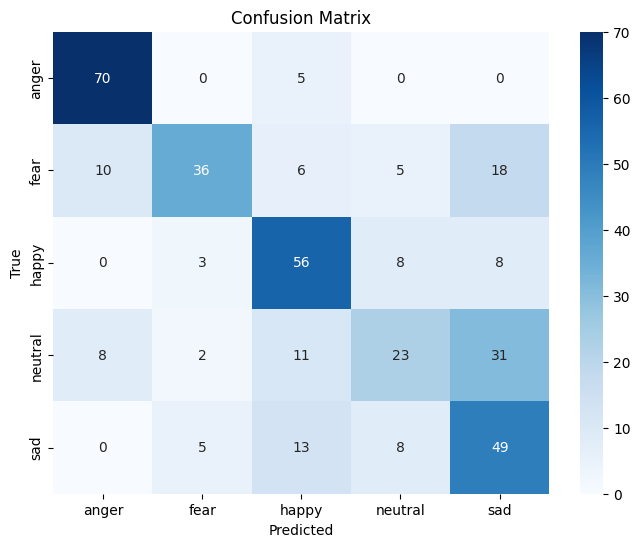

In [6]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Prepare Test Data
Xte = imputer.transform(test[feature_cols])
Xte_s = scaler.transform(Xte)
y_pred_proba = lgbm.predict_proba(Xte_s[:, top_idx])

# 2. Apply the custom thresholds (this is the "efficient" part of your model)
def apply_thresholds(proba, labels, thresholds):
    adj = proba - thresholds.reshape(1, -1)
    pred_idx = np.argmax(adj, axis=1)
    return labels[pred_idx]

y_pred = apply_thresholds(y_pred_proba, labels, thr)

# 3. Print Metrics
print("===== Model Performance Evaluation =====")
print(classification_report(test['emotion_clean'], y_pred))
print(f"Final Accuracy: {accuracy_score(test['emotion_clean'], y_pred):.3f}")

# 4. Confusion Matrix
plt.figure(figsize=(8,6))
cm = confusion_matrix(test['emotion_clean'], y_pred, labels=labels)
sns.heatmap(cm, annot=True, fmt='d', xticklabels=labels, yticklabels=labels, cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

In [8]:
# 1. INSTALL DEPENDENCIES
!pip install catboost lightgbm --quiet

import pandas as pd
import numpy as np
import joblib
import lightgbm as lgb
from sklearn.model_selection import GroupShuffleSplit
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.utils.class_weight import compute_class_weight
from sklearn.ensemble import StackingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from catboost import CatBoostClassifier
from sklearn.metrics import classification_report

# 2. LOAD DATA
df = pd.read_csv('/content/punjabi_audio_features_prosody_with_ids (1).csv').dropna(subset=['emotion_clean'])
feature_cols = [c for c in df.columns if any([
    c.startswith(('mfcc_','chroma_','contrast_')),
    c in ['zcr_mean','zcr_std','rms_mean','rms_std','f0_mean','f0_std','f0_min','f0_max','f0_slope','f0_delta_std','voiced_fraction',
          'jitter_local','shimmer_local','hnr_db','silence_ratio','bursts_per_sec','avg_pause_sec','duration_sec',
          'centroid_mean','centroid_std','bandwidth_mean','bandwidth_std','rolloff50_mean','rolloff85_mean','spectral_slope',
          'F1_mean','F2_mean']
])]



# 3. SPEAKER-WISE SPLIT
gss = GroupShuffleSplit(test_size=0.25, n_splits=1, random_state=42)
tr_idx, te_idx = next(gss.split(df, groups=df['participant']))
train, test = df.iloc[tr_idx].copy(), df.iloc[te_idx].copy()

# 4. PREPROCESSING
train[feature_cols] = train[feature_cols].apply(pd.to_numeric, errors='coerce').replace([np.inf,-np.inf], np.nan)
test[feature_cols] = test[feature_cols].apply(pd.to_numeric, errors='coerce').replace([np.inf,-np.inf], np.nan)

imputer = SimpleImputer(strategy='median')
scaler = StandardScaler()
Xtr_s = scaler.fit_transform(imputer.fit_transform(train[feature_cols]))
Xte_s = scaler.transform(imputer.transform(test[feature_cols]))

# 5. ENCODE LABELS AND CLEAN WEIGHTS
le = LabelEncoder()
ytr_enc = le.fit_transform(train['emotion_clean'].values)
yte_enc = le.transform(test['emotion_clean'].values)

cw_vals = compute_class_weight('balanced', classes=np.unique(ytr_enc), y=ytr_enc)
# CLEANED: Convert all weights to native Python floats
cw_dict = {int(c): float(w) for c, w in zip(np.unique(ytr_enc), cw_vals)}
cw_list = [float(w) for w in cw_vals]

# 6. FEATURE SELECTION
rf_temp = RandomForestClassifier(n_estimators=500, random_state=42, class_weight=cw_dict, n_jobs=-1)
rf_temp.fit(Xtr_s, ytr_enc)
top_features = pd.DataFrame({'f': feature_cols, 'i': rf_temp.feature_importances_}).sort_values('i', ascending=False).head(50)['f'].tolist()
top_idx = [feature_cols.index(c) for c in top_features]
Xtr_k, Xte_k = Xtr_s[:, top_idx], Xte_s[:, top_idx]

# 7. TRAINING BASE MODELS (With CatBoost Wrapper)
from sklearn.base import BaseEstimator, ClassifierMixin

class CatBoostWrapper(BaseEstimator, ClassifierMixin):
    def __init__(self, iterations=1000, depth=6, learning_rate=0.05, class_weights=None):
        self.iterations = iterations
        self.depth = depth
        self.learning_rate = learning_rate
        self.class_weights = class_weights
        self.model = CatBoostClassifier(
            iterations=iterations, depth=depth, learning_rate=learning_rate,
            loss_function='MultiClass', random_seed=42, verbose=False,
            class_weights=class_weights
        )
    def fit(self, X, y):
        self.model.fit(X, y)
        # CRITICAL: Expose the classes_ attribute required by StackingClassifier
        self.classes_ = self.model.classes_
        return self
    def predict(self, X):
        return self.model.predict(X)
    def predict_proba(self, X):
        return self.model.predict_proba(X)
    def get_params(self, deep=True):
        return {"iterations": self.iterations, "depth": self.depth,
                "learning_rate": self.learning_rate, "class_weights": self.class_weights}
    def set_params(self, **params):
        for param, value in params.items():
            setattr(self, param, value)
        return self

# Now initialize models using the wrapper
rf = RandomForestClassifier(n_estimators=500, random_state=42, class_weight=cw_dict, n_jobs=-1)
cb = CatBoostWrapper(iterations=1000, depth=6, learning_rate=0.05, class_weights=[float(w) for w in cw_vals])
lgbm = lgb.LGBMClassifier(n_estimators=1000, learning_rate=0.03, num_leaves=63, random_state=42, class_weight=cw_dict)

rf.fit(Xtr_k, ytr_enc); cb.fit(Xtr_k, ytr_enc); lgbm.fit(Xtr_k, ytr_enc)

# 8. STACKING
stack = StackingClassifier(estimators=[('lgbm', lgbm), ('cb', cb), ('rf', rf)],
                           final_estimator=LogisticRegression(), cv=5, n_jobs=-1)
stack.fit(Xtr_k, ytr_enc)

# 9. EVALUATION
print("\n--- Final Stacking Ensemble Results ---")
print(classification_report(yte_enc, stack.predict(Xte_k), target_names=le.classes_))

# 10. SAVE ARTIFACTS
joblib.dump(imputer, '/content/imputer.joblib')
joblib.dump(scaler, '/content/scaler.joblib')
joblib.dump(stack, '/content/stacking_model.joblib')
joblib.dump(le, '/content/label_encoder.joblib')
pd.Series(top_features).to_csv('/content/topk_features.csv', index=False)
print("✅ Artifacts saved successfully!")

Streaming output truncated to the last 5000 lines.
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with posit

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


              precision    recall  f1-score   support

       anger       0.82      0.96      0.88        75
        fear       0.78      0.47      0.58        75
       happy       0.62      0.73      0.67        75
     neutral       0.49      0.40      0.44        75
         sad       0.51      0.63      0.56        75

    accuracy                           0.64       375
   macro avg       0.64      0.64      0.63       375
weighted avg       0.64      0.64      0.63       375

✅ Artifacts saved successfully!


In [9]:
# 1. INSTALL DEPENDENCIES
!pip install catboost lightgbm --quiet

import pandas as pd
import numpy as np
import joblib
import lightgbm as lgb
from sklearn.model_selection import GroupShuffleSplit
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.utils.class_weight import compute_class_weight
from sklearn.ensemble import StackingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from catboost import CatBoostClassifier
from sklearn.metrics import classification_report
from sklearn.base import BaseEstimator, ClassifierMixin

# --- WRAPPER FOR CATBOOST ---
class CatBoostWrapper(BaseEstimator, ClassifierMixin):
    def __init__(self, iterations=1000, depth=6, learning_rate=0.05, class_weights=None):
        self.iterations = iterations
        self.depth = depth
        self.learning_rate = learning_rate
        self.class_weights = class_weights
        self.model = CatBoostClassifier(
            iterations=iterations, depth=depth, learning_rate=learning_rate,
            loss_function='MultiClass', random_seed=42, verbose=False,
            class_weights=class_weights
        )
    def fit(self, X, y):
        self.model.fit(X, y)
        self.classes_ = self.model.classes_
        return self
    def predict(self, X): return self.model.predict(X)
    def predict_proba(self, X): return self.model.predict_proba(X)
    def get_params(self, deep=True):
        return {"iterations": self.iterations, "depth": self.depth,
                "learning_rate": self.learning_rate, "class_weights": self.class_weights}
    def set_params(self, **params):
        for param, value in params.items(): setattr(self, param, value)
        return self

# 2. LOAD DATA
df = pd.read_csv('/content/punjabi_audio_features_prosody_with_ids (1).csv').dropna(subset=['emotion_clean'])
feature_cols = [c for c in df.columns if any([
    c.startswith(('mfcc_','chroma_','contrast_')),
    c in ['zcr_mean','zcr_std','rms_mean','rms_std','f0_mean','f0_std','f0_min','f0_max','f0_slope','f0_delta_std','voiced_fraction',
          'jitter_local','shimmer_local','hnr_db','silence_ratio','bursts_per_sec','avg_pause_sec','duration_sec',
          'centroid_mean','centroid_std','bandwidth_mean','bandwidth_std','rolloff50_mean','rolloff85_mean','spectral_slope',
          'F1_mean','F2_mean']
])]

# 3. SPEAKER-WISE SPLIT
gss = GroupShuffleSplit(test_size=0.25, n_splits=1, random_state=42)
tr_idx, te_idx = next(gss.split(df, groups=df['participant']))
train, test = df.iloc[tr_idx].copy(), df.iloc[te_idx].copy()

# 4. PREPROCESSING
train[feature_cols] = train[feature_cols].apply(pd.to_numeric, errors='coerce').replace([np.inf,-np.inf], np.nan)
test[feature_cols] = test[feature_cols].apply(pd.to_numeric, errors='coerce').replace([np.inf,-np.inf], np.nan)

imputer = SimpleImputer(strategy='median')
scaler = StandardScaler()
Xtr_s = scaler.fit_transform(imputer.fit_transform(train[feature_cols]))
Xte_s = scaler.transform(imputer.transform(test[feature_cols]))

# 5. LABEL ENCODING & WEIGHTS
le = LabelEncoder()
ytr_enc = le.fit_transform(train['emotion_clean'].values)
yte_enc = le.transform(test['emotion_clean'].values)

cw_vals = compute_class_weight('balanced', classes=np.unique(ytr_enc), y=ytr_enc)
cw_dict = {int(c): float(w) for c, w in zip(np.unique(ytr_enc), cw_vals)}
cw_list = [float(w) for w in cw_vals]

# 6. FEATURE SELECTION
rf_temp = RandomForestClassifier(n_estimators=500, random_state=42, class_weight=cw_dict, n_jobs=-1)
rf_temp.fit(Xtr_s, ytr_enc)
top_features = pd.DataFrame({'f': feature_cols, 'i': rf_temp.feature_importances_}).sort_values('i', ascending=False).head(50)['f'].tolist()
top_idx = [feature_cols.index(c) for c in top_features]
Xtr_k, Xte_k = Xtr_s[:, top_idx], Xte_s[:, top_idx]

# 7. TRAINING BASE MODELS
rf = RandomForestClassifier(n_estimators=500, random_state=42, class_weight=cw_dict, n_jobs=-1)
cb = CatBoostWrapper(iterations=1000, depth=6, learning_rate=0.05, class_weights=cw_list)
lgbm = lgb.LGBMClassifier(n_estimators=1000, learning_rate=0.03, num_leaves=63, random_state=42, class_weight=cw_dict)

# 8. STACKING
stack = StackingClassifier(estimators=[('lgbm', lgbm), ('cb', cb), ('rf', rf)],
                           final_estimator=LogisticRegression(), cv=5, n_jobs=-1)
stack.fit(Xtr_k, ytr_enc)

# 9. EVALUATION
print("\n--- Final Stacking Ensemble Results ---")
print(classification_report(yte_enc, stack.predict(Xte_k), target_names=le.classes_))

# 10. SAVE ARTIFACTS
joblib.dump(imputer, '/content/imputer.joblib')
joblib.dump(scaler, '/content/scaler.joblib')
joblib.dump(stack, '/content/stacking_model.joblib')
joblib.dump(le, '/content/label_encoder.joblib')
pd.Series(top_features).to_csv('/content/topk_features.csv', index=False)
print("✅ Artifacts saved to /content/")


--- Final Stacking Ensemble Results ---


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


              precision    recall  f1-score   support

       anger       0.82      0.96      0.88        75
        fear       0.78      0.47      0.58        75
       happy       0.62      0.73      0.67        75
     neutral       0.49      0.40      0.44        75
         sad       0.51      0.63      0.56        75

    accuracy                           0.64       375
   macro avg       0.64      0.64      0.63       375
weighted avg       0.64      0.64      0.63       375

✅ Artifacts saved to /content/


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Confusion Matrix:
[[72  0  3  0  0]
 [ 9 35  8  7 16]
 [ 1  2 55 14  3]
 [ 6  2 10 30 27]
 [ 0  6 12 10 47]]


<Figure size 800x600 with 0 Axes>

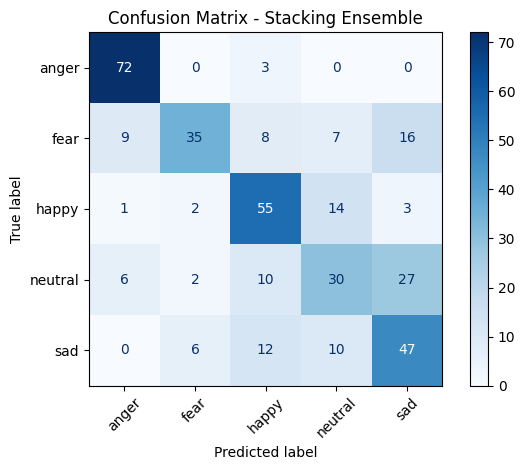

In [10]:
# 9.5 CONFUSION MATRIX
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Predictions
y_pred = stack.predict(Xte_k)

# Confusion Matrix
cm = confusion_matrix(yte_enc, y_pred)

print("Confusion Matrix:")
print(cm)

# Plot
plt.figure(figsize=(8,6))
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=le.classes_
)
disp.plot(cmap="Blues", values_format='d')
plt.title("Confusion Matrix - Stacking Ensemble")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()